In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt, butter
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

In [6]:
data = pd.read_csv("E:\eeg-analysis\Aritmethic Calculation.txt", skiprows=4)
data.columns = data.columns.str.strip()

<>:1: SyntaxWarning: invalid escape sequence '\e'
<>:1: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Alyssa\AppData\Local\Temp\ipykernel_13088\2077648512.py:1: SyntaxWarning: invalid escape sequence '\e'
  data = pd.read_csv("E:\eeg-analysis\Aritmethic Calculation.txt", skiprows=4)


In [7]:
print(Path('..'))

..


In [ ]:
base_dir = Path('../Experiment')

data = {
    'viat-map': [],
    'reading': [],
    'relax': [],
    'go-nogo': []
}

for subject_folder in base_dir.iterdir():
    if subject_folder.is_dir():
        for category in data.keys():
            pattern = f"{category}*.txt"
            for file in subject_folder.glob(pattern):
                df = pd.read_csv(file, skiprows=4)
                data[category].append(df)

viat_map_df = pd.concat(data['viat-map'], ignore_index=True)
reading_df = pd.concat(data['reading'], ignore_index=True)
relax_df = pd.concat(data['relax'], ignore_index=True)
go_nogo_df = pd.concat(data['go-nogo'], ignore_index=True)

ValueError: No objects to concatenate

In [8]:
label = 'resting' # Label Sinyal Saat Ini
start_from_minutes = 1 # Dimulai Dari Menit
start_from_seconds = 23 # Dimulai Dari Detik
end_from_minutes = 3 # Selesai Pada Menit
end_from_seconds = 21 # Selesai Pada Detik

In [9]:
window_size = 250  # Ukuran window (contoh: 1 detik dengan sampling rate 250 Hz)
step_size = 125    # Overlap 50%

def apply_windowing(data, window_size, step_size):
    windows = []
    for start in range(0, len(data) - window_size, step_size):
        window = data[start:start + window_size]
        windows.append(window)
    return np.array(windows)

In [10]:
fs = 250  # Sampling rate (contoh: 250 Hz)
f0 = 50   # Frekuensi yang ingin dihilangkan (contoh: 50 Hz)
quality_factor = 30

def apply_notch_filter(data, f0, fs, quality_factor):
    # Hitung frekuensi normalisasi
    nyquist = 0.5 * fs
    freq = f0 / nyquist
    
    # Buat filter notch
    b, a = iirnotch(freq, quality_factor)
    
    # Terapkan filter
    filtered_data = filtfilt(b, a, data)
    return filtered_data

In [11]:
lowcut = 0.5  # Frekuensi cutoff rendah (contoh: 0.5 Hz)
highcut = 40  # Frekuensi cutoff tinggi (contoh: 40 Hz)

# Fungsi untuk menerapkan bandpass filter
def apply_bandpass_filter(data, lowcut, highcut, fs, order=5):
    # Hitung frekuensi normalisasi
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    
    # Buat filter bandpass
    b, a = butter(order, [low, high], btype='band')
    
    # Terapkan filter
    filtered_data = filtfilt(b, a, data)
    return filtered_data

In [12]:
def process_signal_channel(signal, fs, f0=50, quality_factor=30, lowcut=0.5, highcut=40, window_size=250, step_size=125):
    # Notch filter
    signal = apply_notch_filter(signal, f0, fs, quality_factor)
    
    # Bandpass filter
    signal = apply_bandpass_filter(signal, lowcut, highcut, fs)
    
    # Windowing
    windows = apply_windowing(signal, window_size, step_size)
    
    return windows

In [13]:
def process_dataframe(df, fs, exclude_columns=['time', 'subject']):
    processed = {}
    signal_columns = df.select_dtypes(include='number').columns.difference(exclude_columns)
    
    for col in signal_columns:
        processed[col] = process_signal_channel(df[col].values, fs)
    
    return processed  # dict of {channel_name: windowed_array}

In [14]:
def combine_channels(processed_dict):
    # Convert dict to list of arrays
    channels = list(processed_dict.values())
    
    # Stack: shape (num_channels, num_windows, window_size)
    combined = np.stack(channels, axis=0)
    
    # Optional: swap axis to (num_windows, num_channels, window_size)
    return np.transpose(combined, (1, 0, 2))

In [16]:
viat_map_processed = process_dataframe(viat_map_df, fs)
viat_map_array = combine_channels(viat_map_processed)

NameError: name 'viat_map_df' is not defined

In [15]:
print(viat_map_processed.keys())

NameError: name 'viat_map_processed' is not defined

In [17]:
# Misal dari hasil windowing
channel_windows = viat_map_processed[' EXG Channel 2']  # shape (num_windows, window_size)

plt.figure(figsize=(15, 8))
for i in range(5):  # plot 5 window pertama
    plt.subplot(5, 1, i+1)
    plt.plot(channel_windows[i], color='purple')
    plt.title(f'Window {i+1}')
    plt.ylabel('Amplitude')
    if i == 4:
        plt.xlabel('Sample')
    else:
        plt.xticks([])
    plt.tight_layout()
plt.show()


NameError: name 'viat_map_processed' is not defined

In [18]:
windows_per_channel = {}  # Dictionary untuk menyimpan window dari setiap channel
normalized_windows_per_channel = {}  # Dictionary untuk menyimpan window yang sudah dinormalisasi
filtered_windows_per_channel = {}  # Dictionary untuk menyimpan window yang sudah difilter

for channel in data.columns[1:9]:  # Kolom 1 hingga 8 adalah EXG Channel 0 hingga 7
    # Ambil data channel
    channel_data = data[channel].values
    
    # Terapkan windowing
    windows = apply_windowing(channel_data, window_size, step_size)
    windows_per_channel[channel] = windows
    
    # Normalisasi setiap window
    normalized_windows = []
    for window in windows:
        scaler = MinMaxScaler(feature_range=(-1, 1))  # Normalisasi ke rentang [-1, 1]
        normalized_window = scaler.fit_transform(window.reshape(-1, 1)).flatten()
        normalized_windows.append(normalized_window)
    normalized_windows_per_channel[channel] = np.array(normalized_windows)
    
    # Terapkan notch filter dan bandpass filter pada setiap window yang sudah dinormalisasi
    filtered_windows = []
    for window in normalized_windows:
        # Notch filter
        notch_filtered_window = apply_notch_filter(window, f0, fs, quality_factor)
        # Bandpass filter
        bandpass_filtered_window = apply_bandpass_filter(notch_filtered_window, lowcut, highcut, fs)
        filtered_windows.append(bandpass_filtered_window)
    filtered_windows_per_channel[channel] = np.array(filtered_windows)
    
    # Cetak jumlah window untuk channel ini
    print(f"Jumlah window untuk {channel}: {len(windows)}")

Jumlah window untuk -92240.55316931644: 90
Jumlah window untuk -91310.74295172012: 90
Jumlah window untuk -92339.34787980889: 90
Jumlah window untuk -92090.21533611004: 90
Jumlah window untuk -91563.92116116539: 90
Jumlah window untuk -92170.01106381549: 90
Jumlah window untuk -91796.60282094513: 90
Jumlah window untuk -91459.20323839226: 90


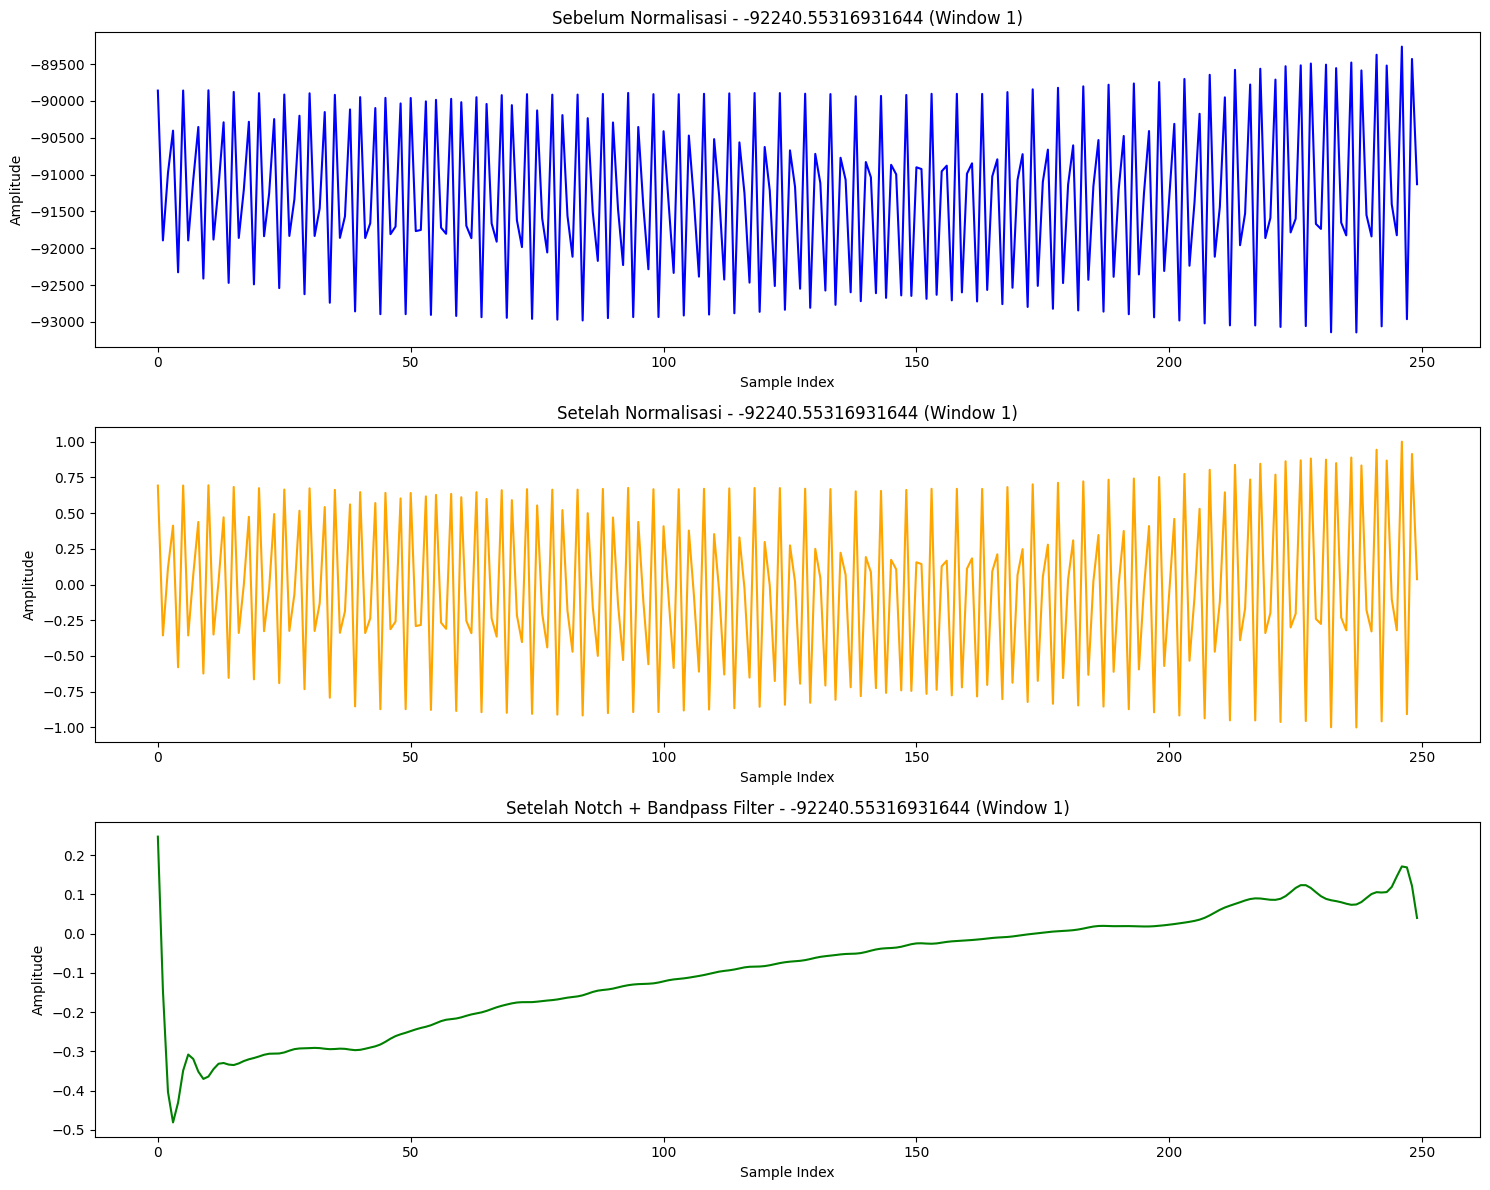

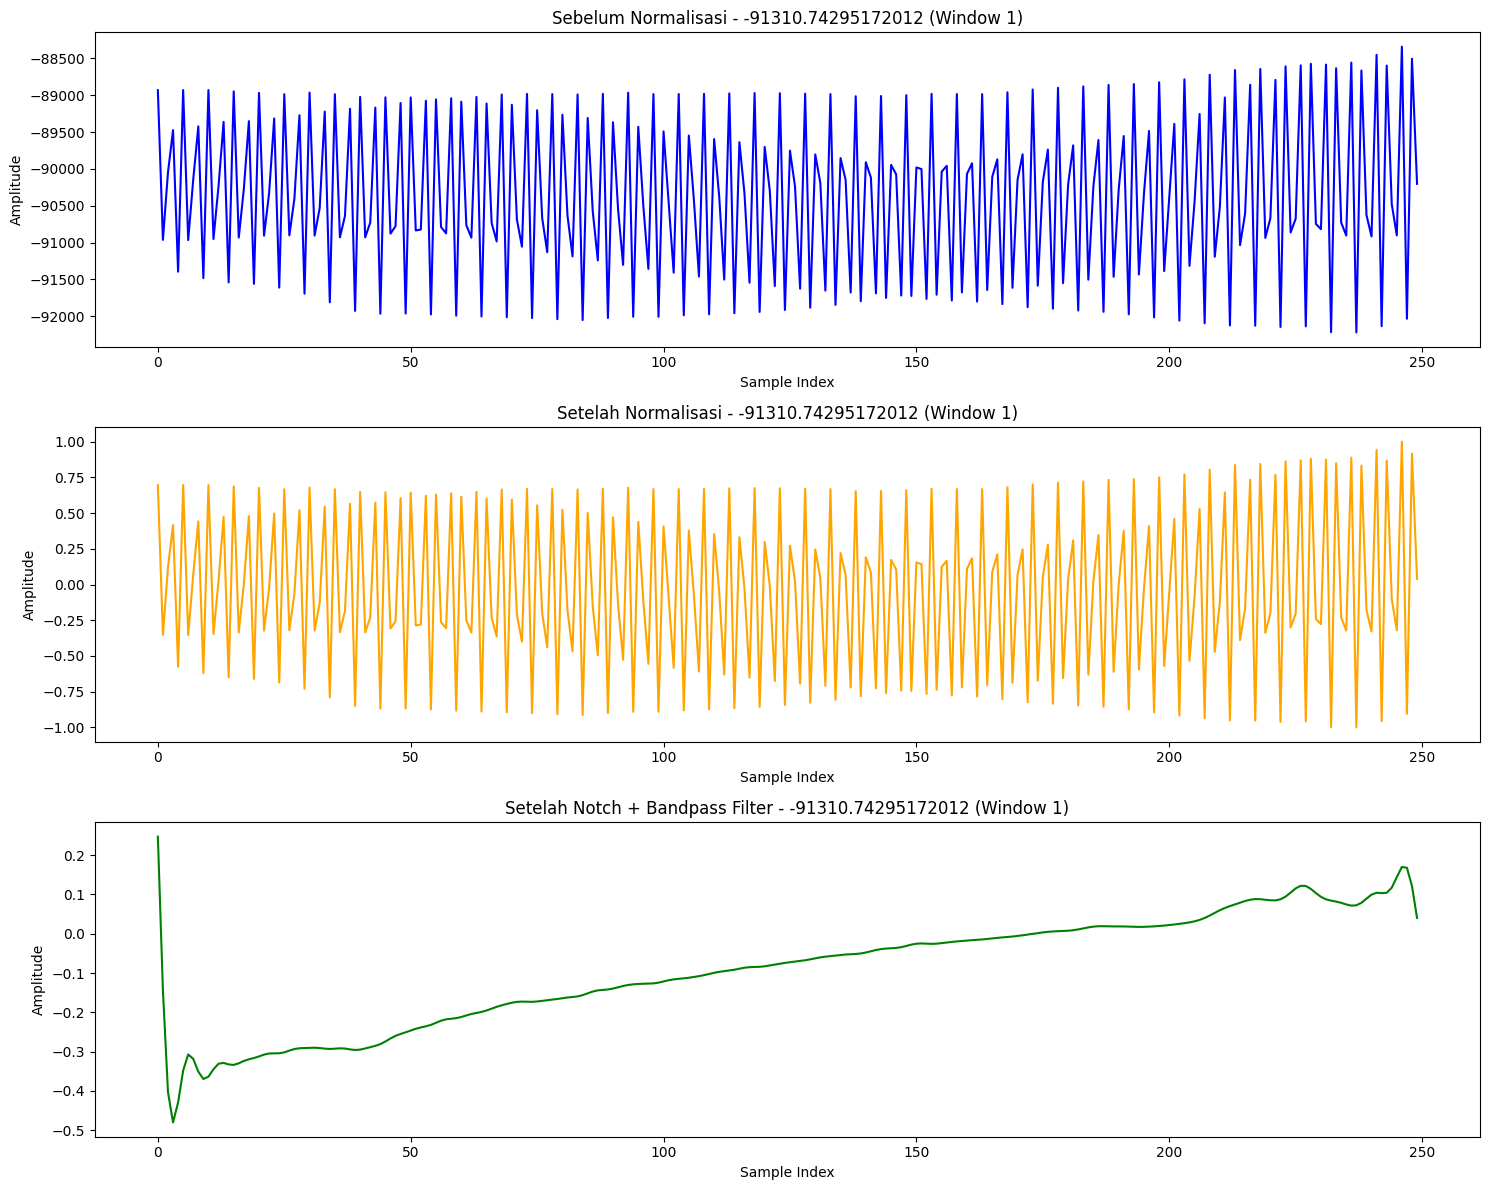

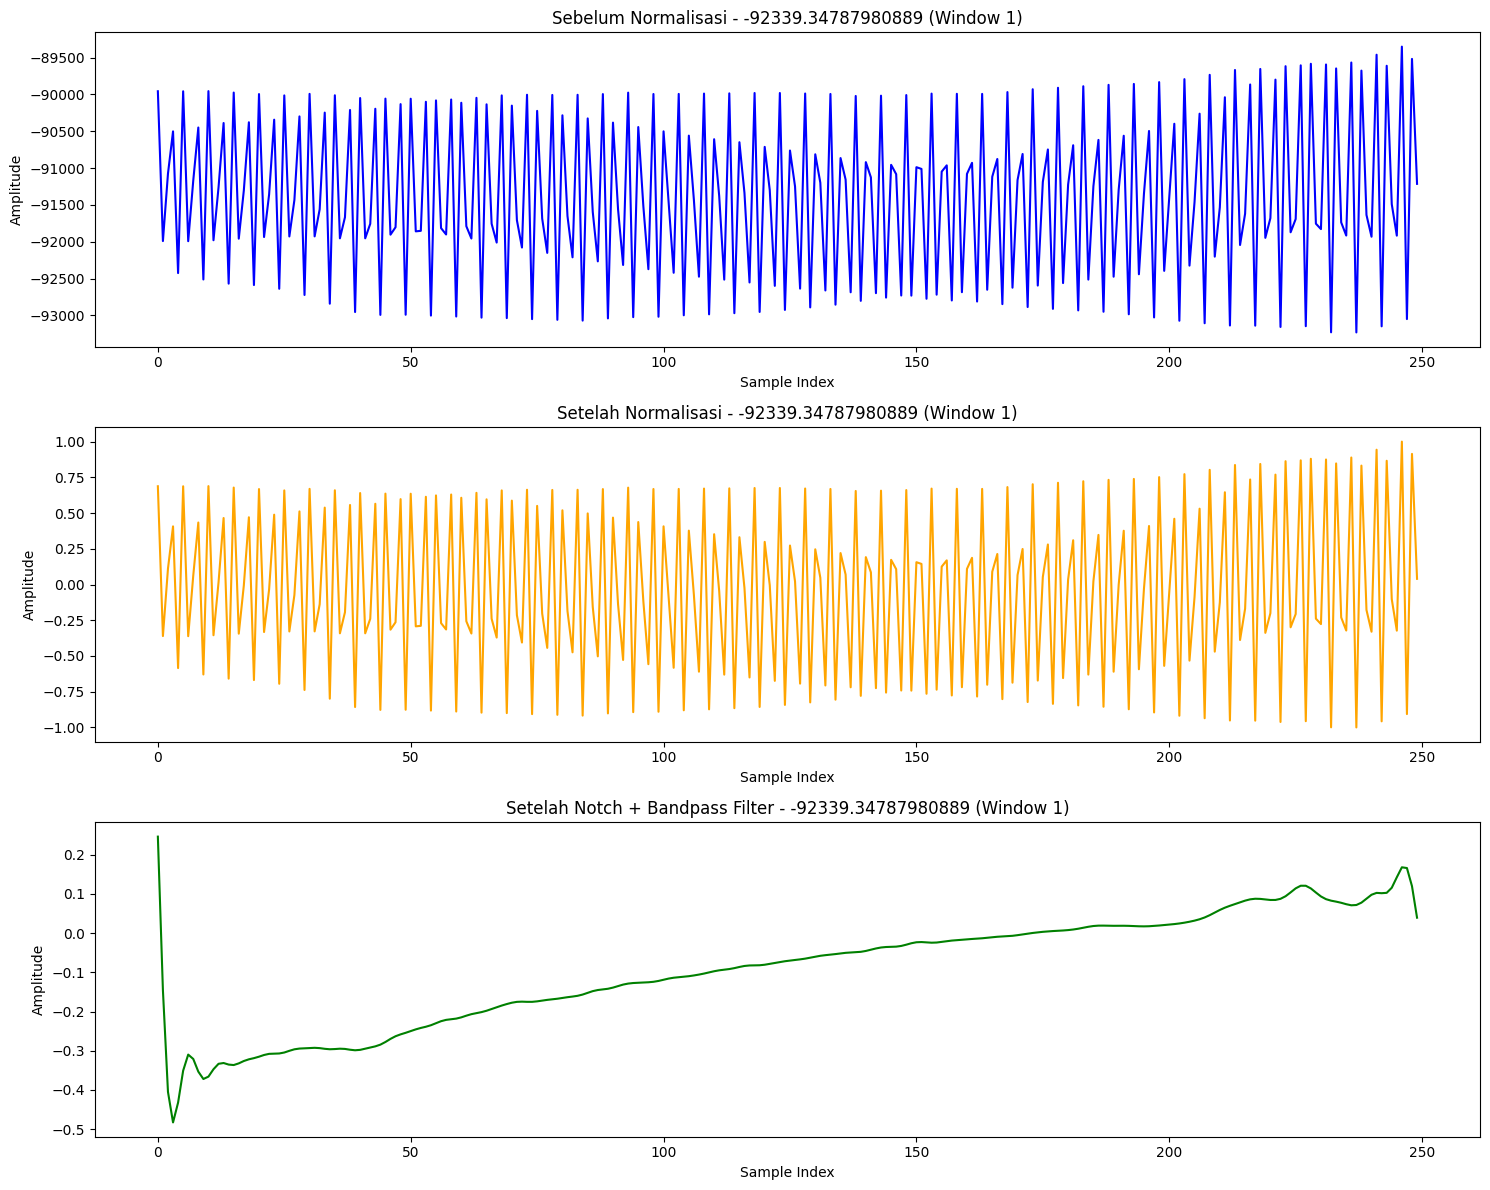

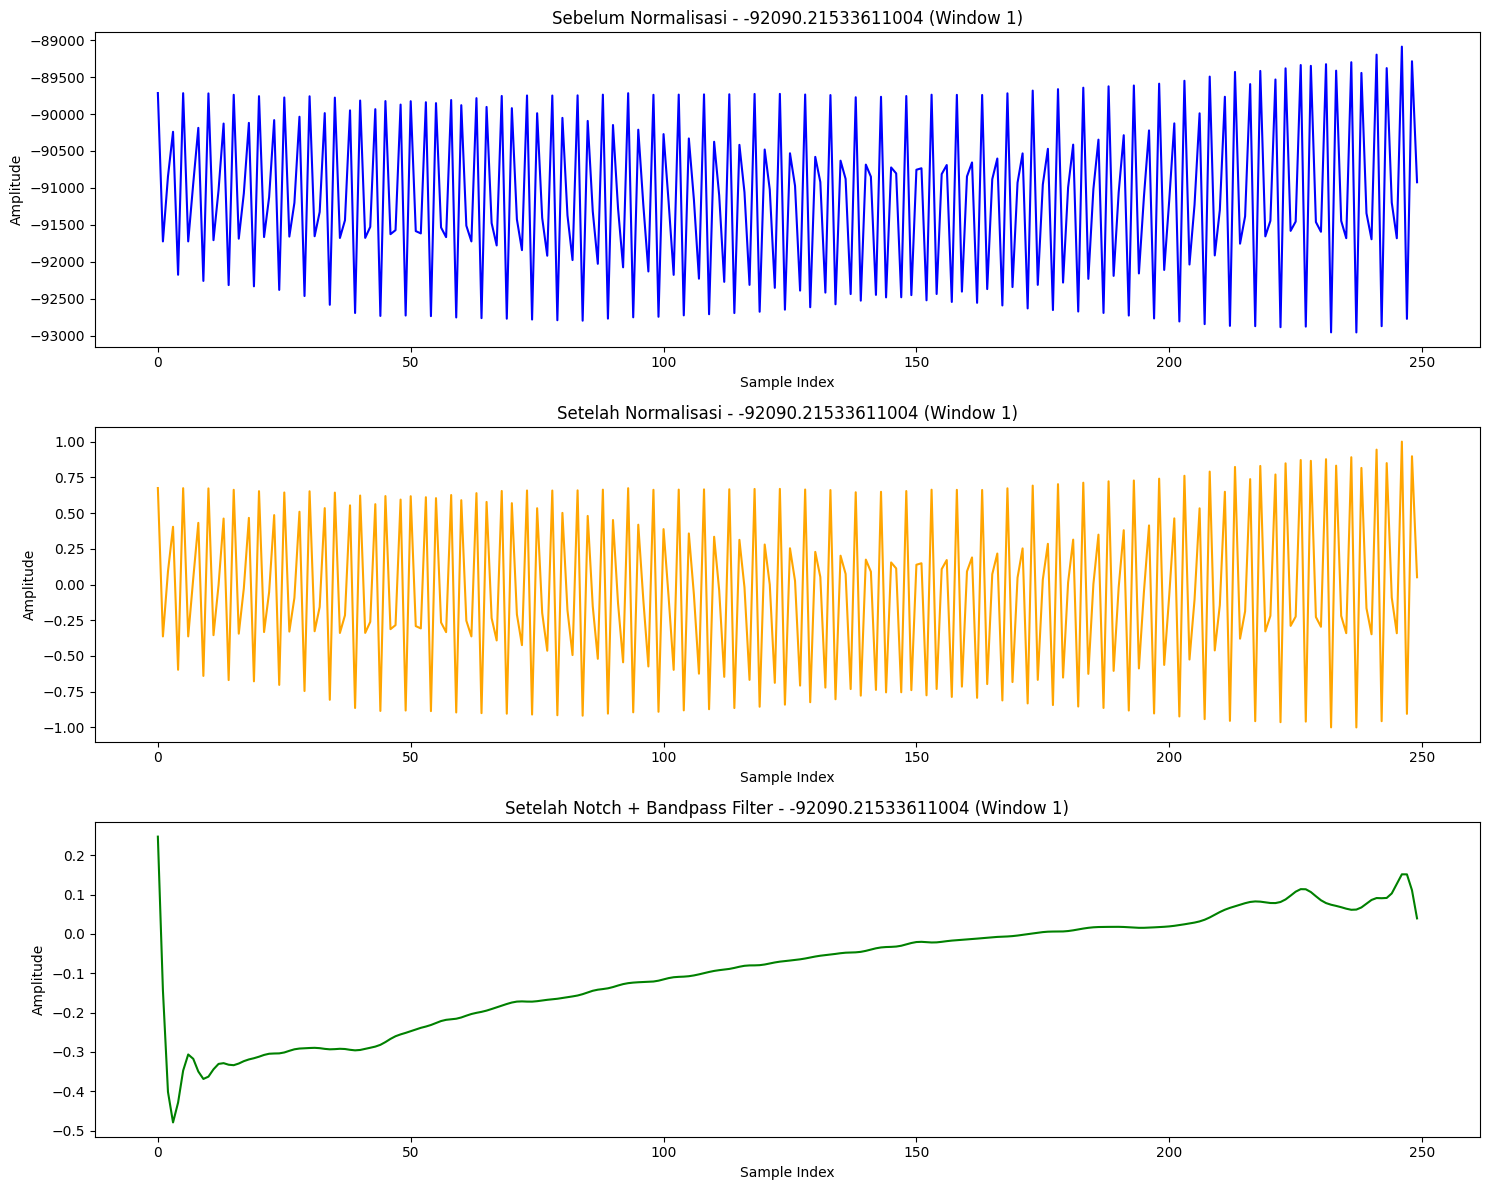

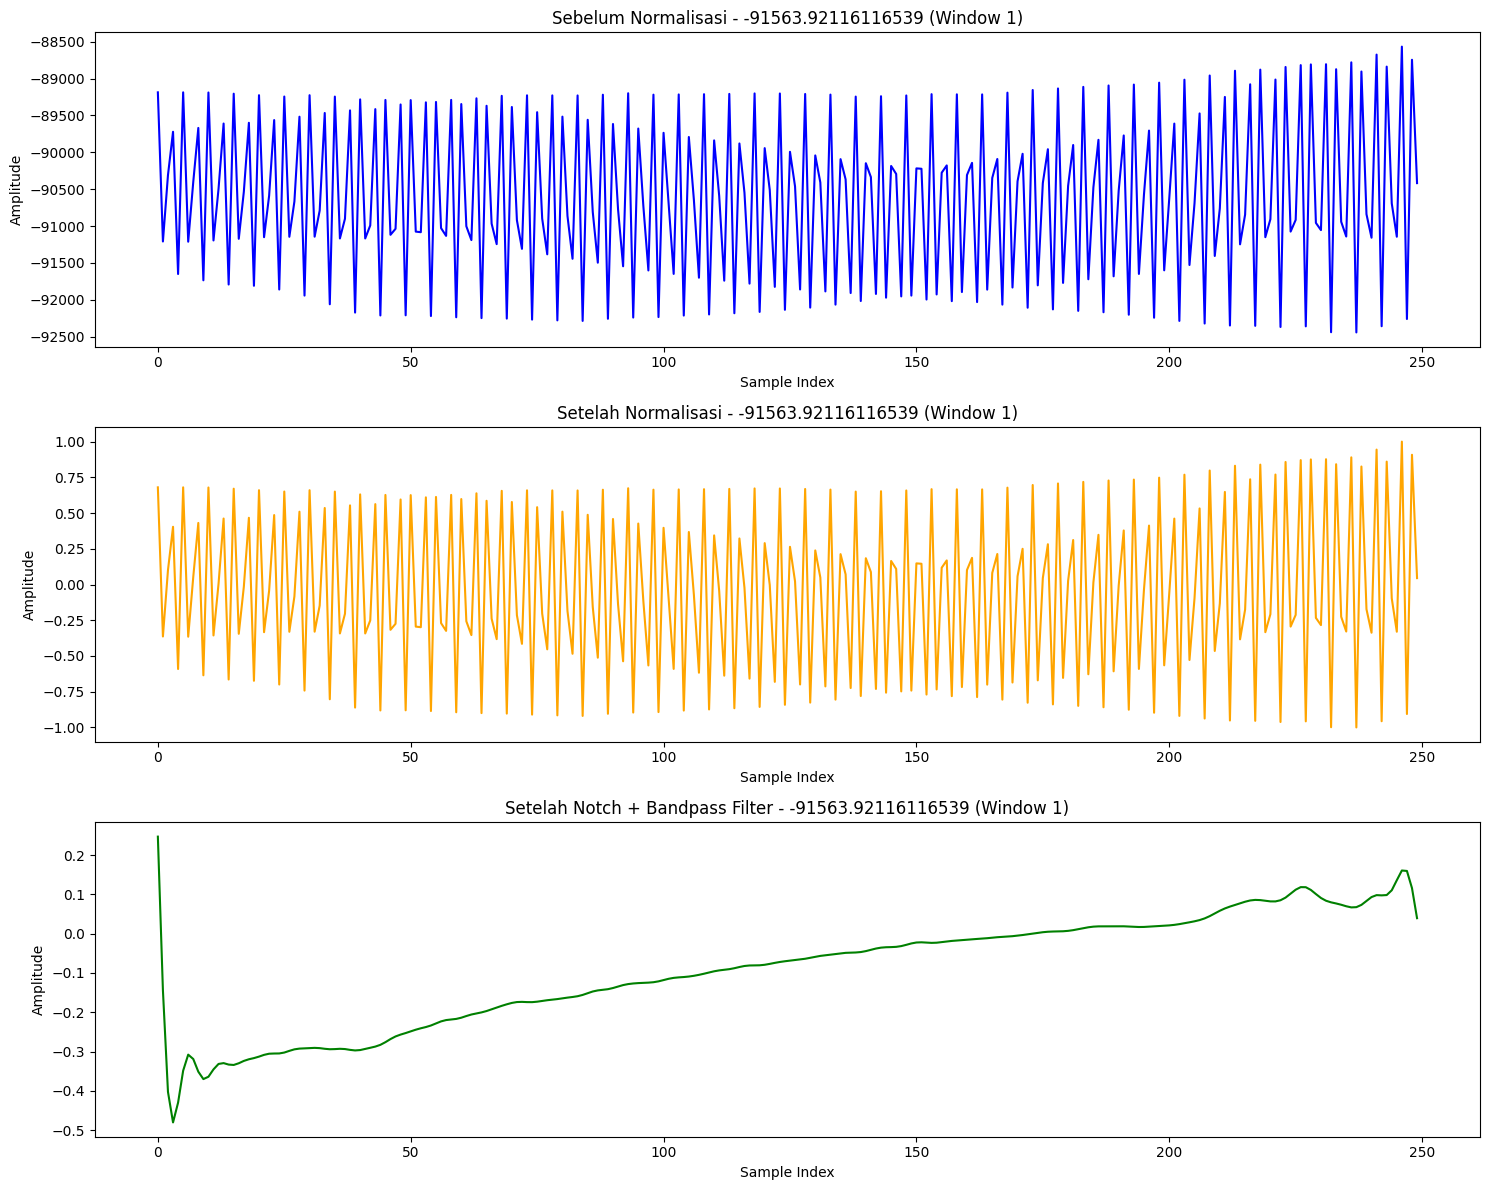

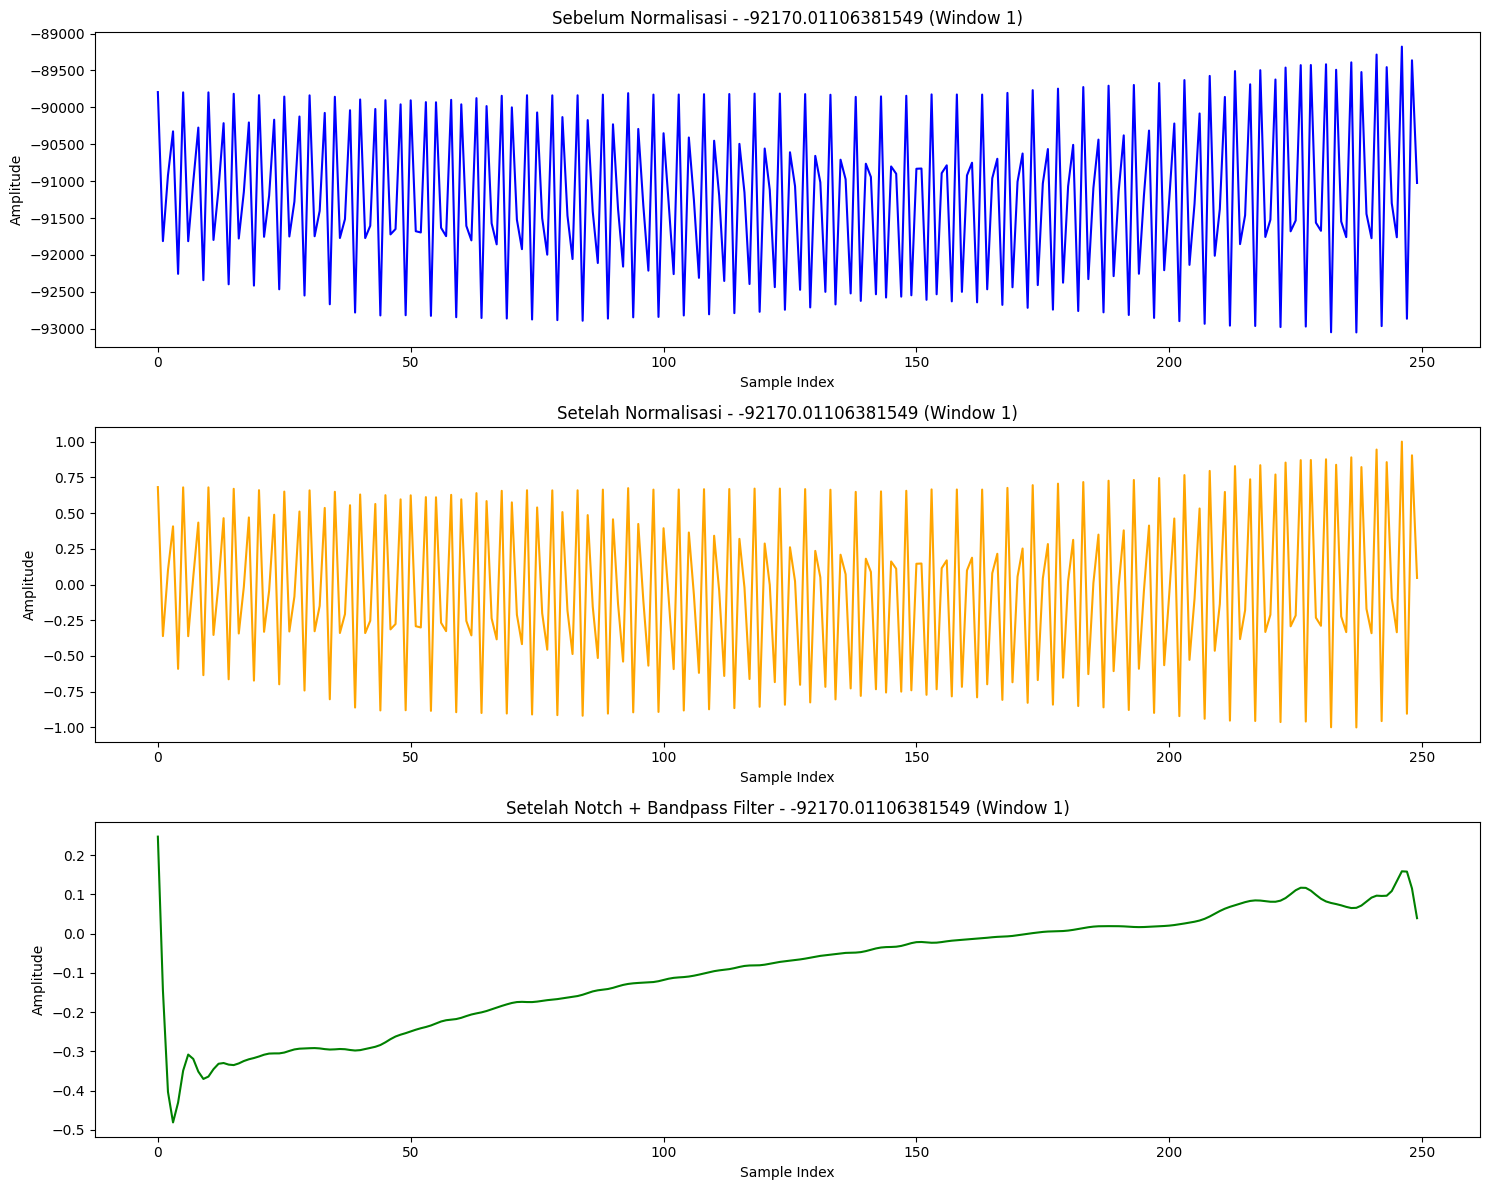

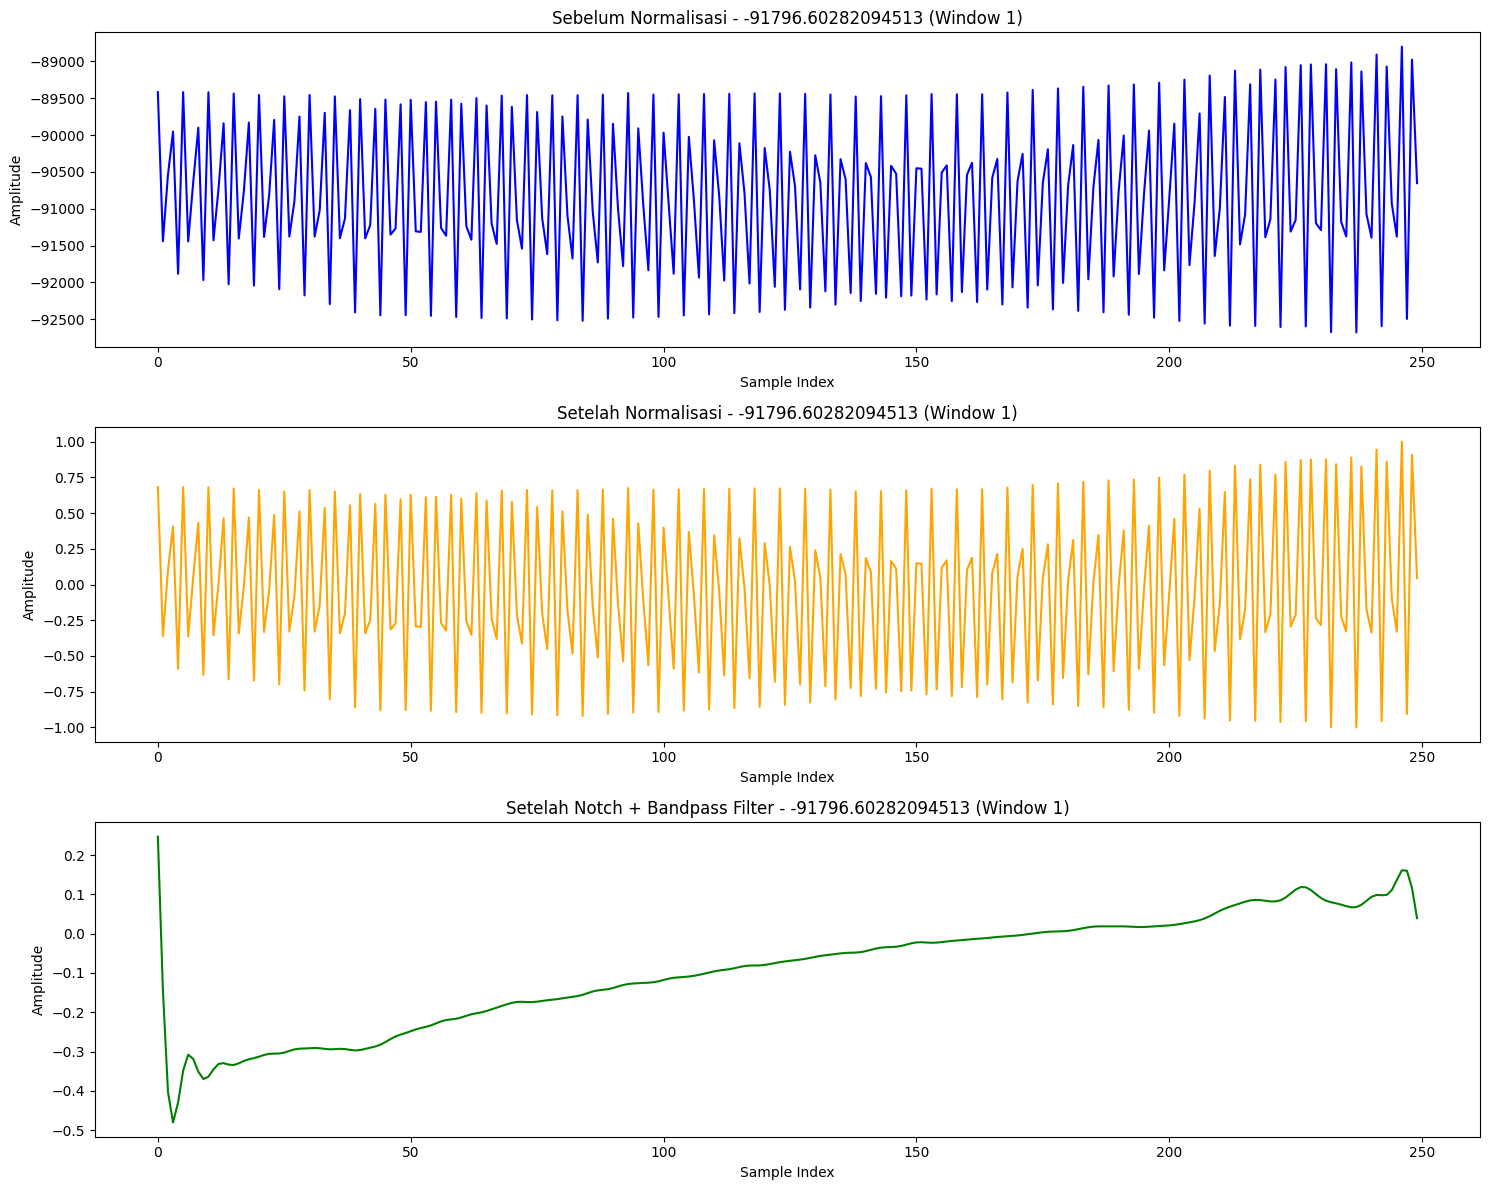

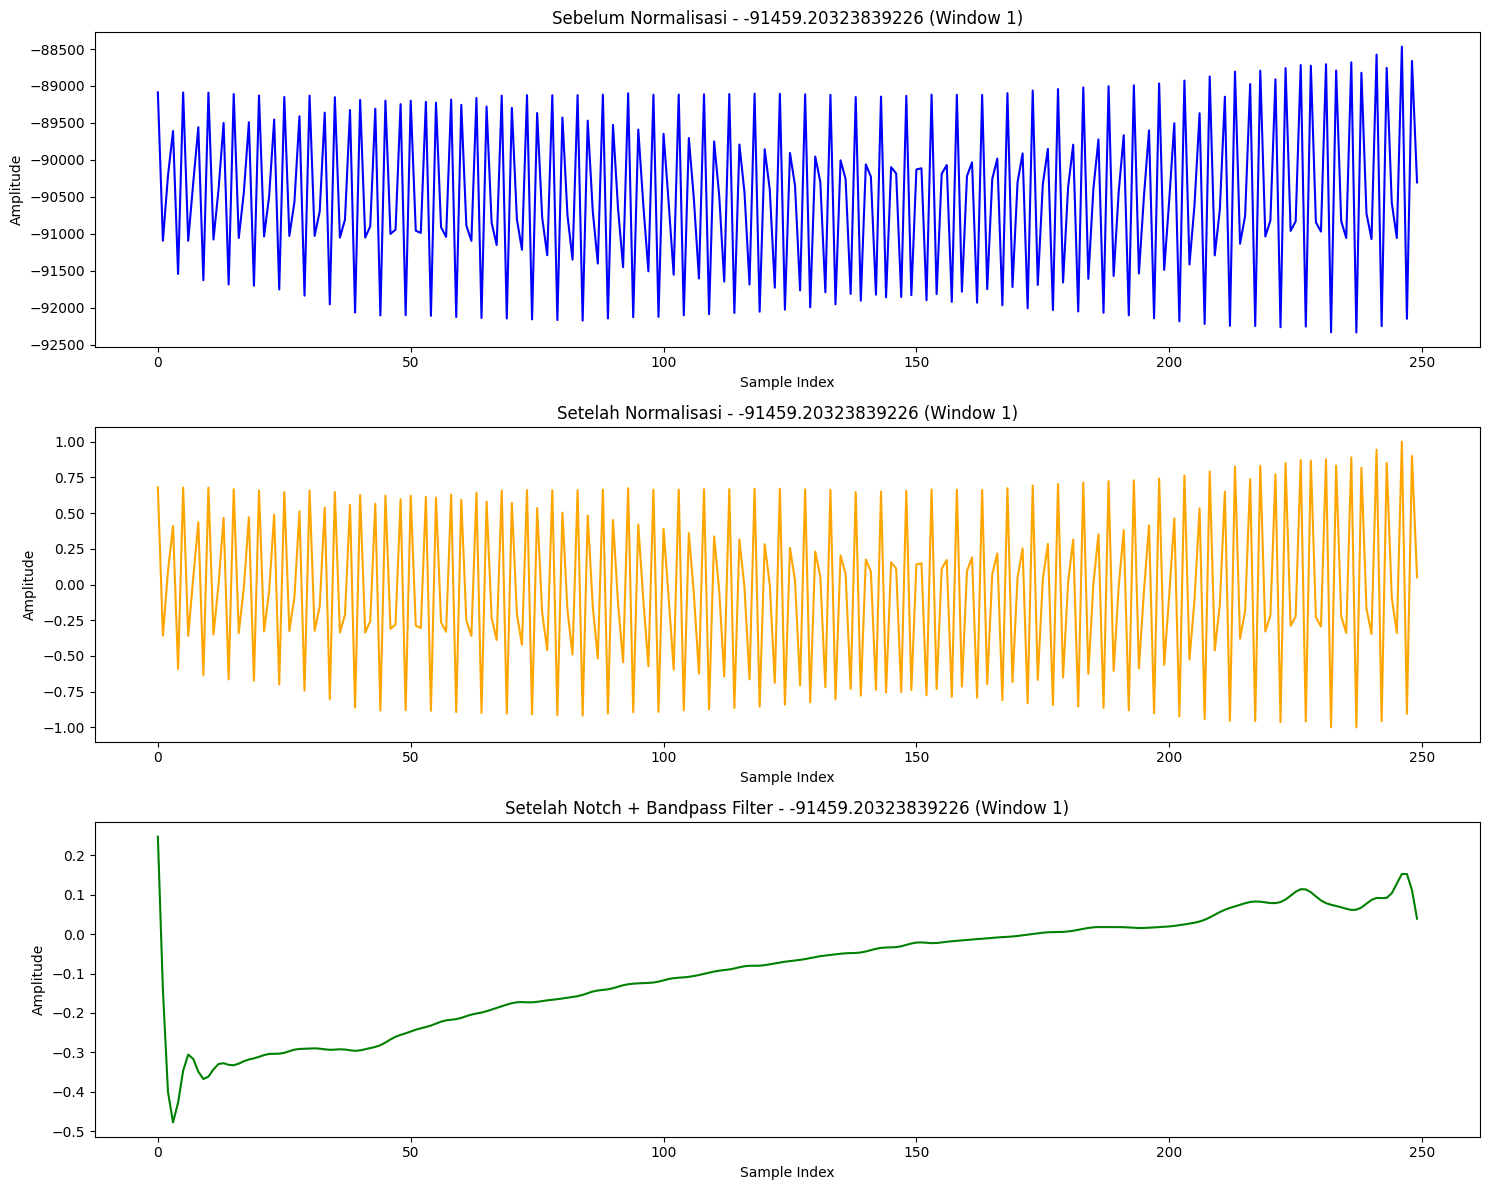

In [19]:
for channel in data.columns[1:9]:  # Loop melalui setiap channel
    plt.figure(figsize=(15, 12))
    
    # Ambil window pertama untuk contoh visualisasi
    window_before = windows_per_channel[channel][0]
    window_normalized = normalized_windows_per_channel[channel][0]
    window_filtered = filtered_windows_per_channel[channel][0]
    
    # Plot sebelum normalisasi
    plt.subplot(3, 1, 1)
    plt.plot(window_before, color='blue')
    plt.title(f"Sebelum Normalisasi - {channel} (Window 1)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    
    # Plot setelah normalisasi
    plt.subplot(3, 1, 2)
    plt.plot(window_normalized, color='orange')
    plt.title(f"Setelah Normalisasi - {channel} (Window 1)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    
    # Plot setelah filtering (notch + bandpass)
    plt.subplot(3, 1, 3)
    plt.plot(window_filtered, color='green')
    plt.title(f"Setelah Notch + Bandpass Filter - {channel} (Window 1)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    
    plt.tight_layout()
    plt.show()

In [21]:
import pandas as pd

# Buat DataFrame untuk menyimpan hasil pemrosesan
processed_data = {}

# Loop melalui setiap channel
for channel in data.columns[1:9]:  # Kolom 1 hingga 8 adalah EXG Channel 0 hingga 7
    # Gabungkan semua window untuk channel ini
    processed_windows = filtered_windows_per_channel[channel]
    
    # Simpan ke DataFrame
    for i, window in enumerate(processed_windows):
        processed_data[f"{channel}_Window_{i + 1}"] = window

# Konversi dictionary ke DataFrame
processed_df = pd.DataFrame(processed_data)

# Simpan ke file CSV
processed_df.to_csv('E:\eeg-analysis\Aritmethic_Calculation.csv', index=False)
print("Data berhasil disimpan ke 'processed_eeg_data.csv'")

<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Alyssa\AppData\Local\Temp\ipykernel_13088\4260102159.py:19: SyntaxWarning: invalid escape sequence '\e'
  processed_df.to_csv('E:\eeg-analysis\Aritmethic_Calculation.csv', index=False)


Data berhasil disimpan ke 'processed_eeg_data.csv'
